In [1]:
# LIBRARIES
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D

# COLORS
colors = ['#5F5449', '#AB5E61', '#B09398', '#CEDFD9', '#718786']

# Data Preparation

In [2]:
# Loading training data
data = np.load('fashion_train.npy')
print(data)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 3]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]]


In [3]:
# Separate data into features and labels
X_train = data[:, :-1]  # Features (first 784 columns)
y = data[:, -1]   # Labels (785th column)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Shirt']

# Standardize feature values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

## Data distribution

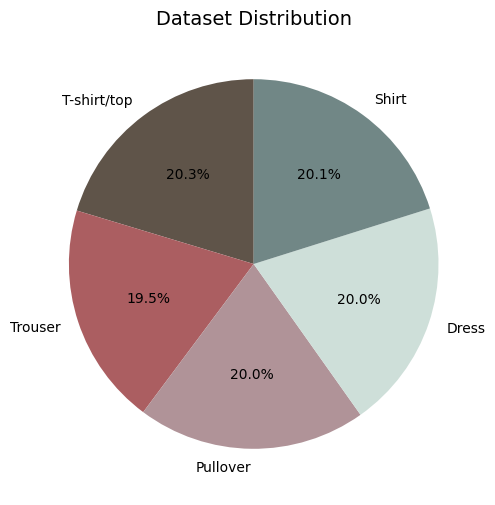

In [4]:
# Counts number of clothes in each category
categories, counts = np.unique(y, return_counts=True)

#  Plotting pie chart
plt.figure(figsize=(8, 6))
plt.pie(counts, labels=class_names, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Dataset Distribution', fontsize=14)
plt.show()

## Data sample

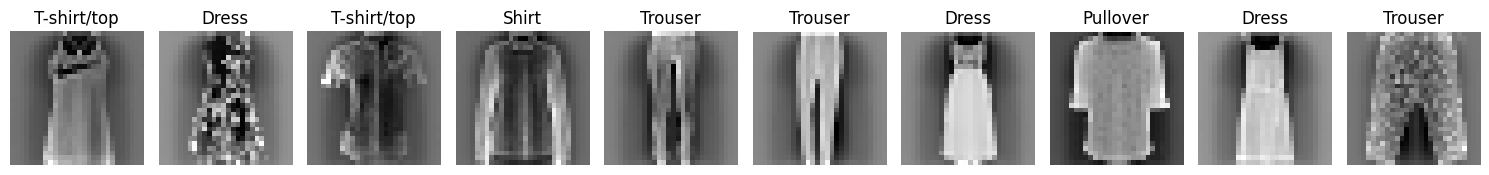

In [5]:
random.seed(42)

# Select k random images
k = 10
random_indexes = random.sample(range(len(X_scaled)), k)

# --- PLOTTING ---
plt.figure(figsize=(15, 6))

for i, index in enumerate(random_indexes):
    # Get the image and label
    random_image = X_scaled[index].reshape(28, 28)  # Reshape the flattened image back to 28x28
    random_label = y[index]
    
    # Plot each image
    plt.subplot(1, k, i + 1)
    plt.imshow(random_image, cmap='gray')
    plt.title(f'{class_names[random_label]}', fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

# PCA

### Scree plot and cumulative variance explained by PCs plot

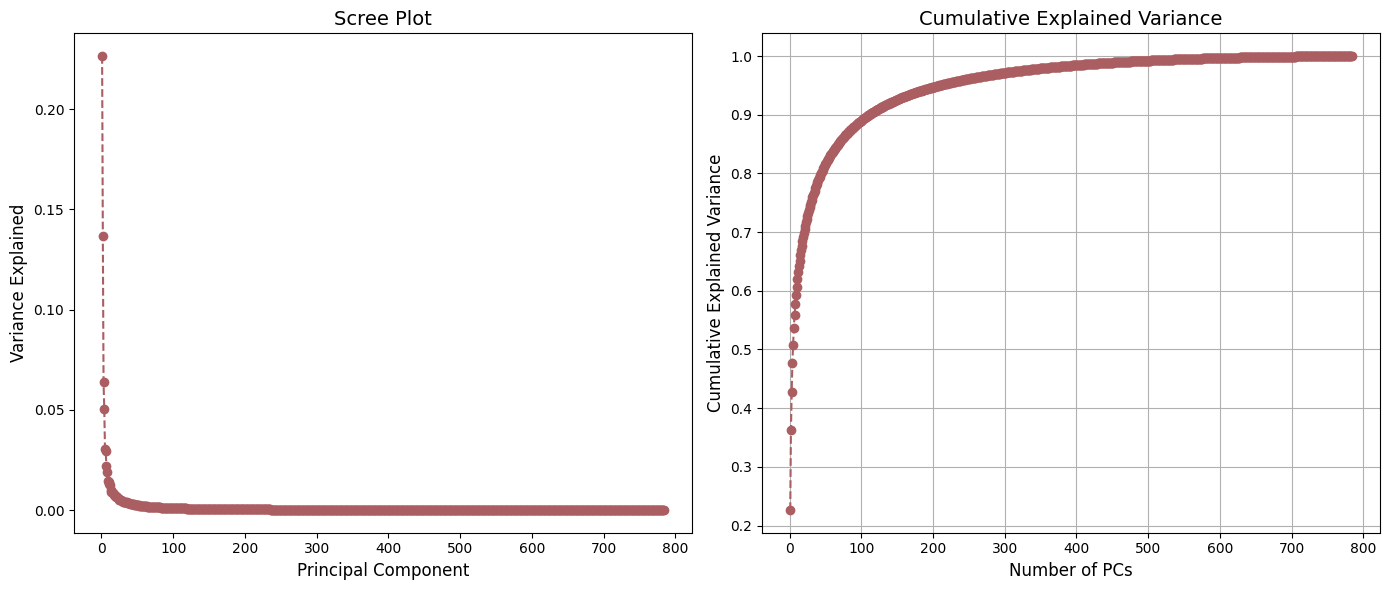

In [6]:
# Apply PCA
pca = PCA()
pca.fit(X_scaled)

#  --- PLOTTING ---
explained_variance_ratio = pca.explained_variance_ratio_
explained_variance = np.cumsum(explained_variance_ratio)

# Plotting area
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1: Scree Plot
axes[0].plot(range(1, len(explained_variance_ratio)+1), explained_variance_ratio, 
             marker='o', linestyle='--', c='#AB5E61')
axes[0].set_title('Scree Plot', fontsize=14)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Variance Explained', fontsize=12)

# 2 Cumulative Explained Variance
axes[1].plot(np.arange(1, len(explained_variance) + 1), explained_variance, 
             marker='o', linestyle='--', c='#AB5E61')
axes[1].set_title('Cumulative Explained Variance', fontsize=14)
axes[1].set_xlabel('Number of PCs', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Exact amount of variance explained by first K PCs

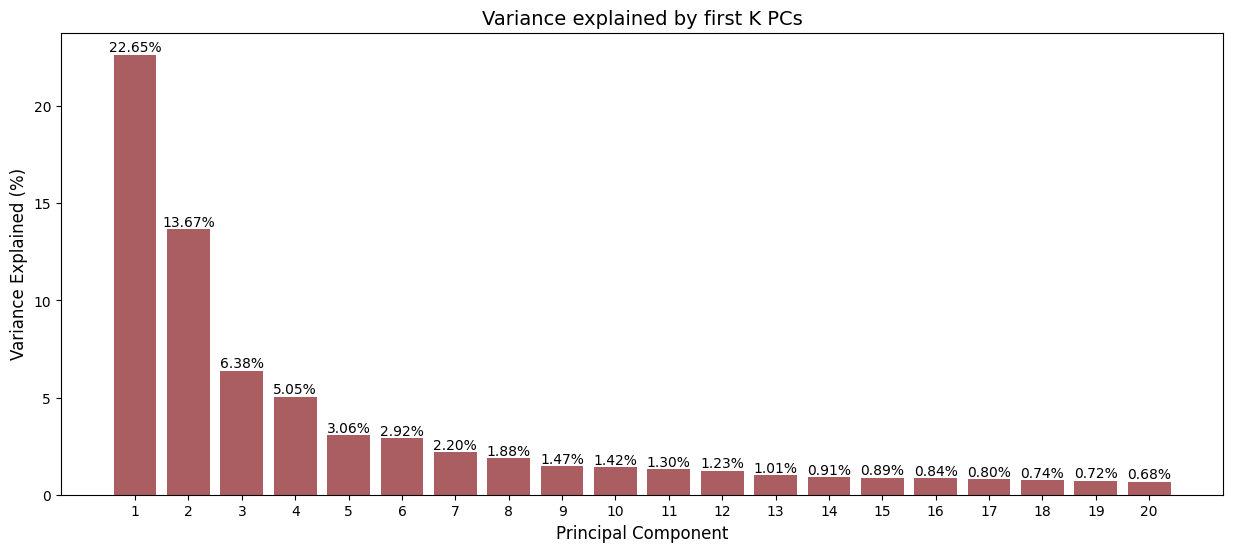

In [7]:
# Plotting the first K principal components
K = 20

# --- PLOTTING ---
plt.figure(figsize=(15, 6))
bars = plt.bar(range(1, K+1), pca.explained_variance_ratio_[:K] * 100, color='#AB5E61')  # Fix: 'color' instead of 'colors'

# Percentage labels on top of each bar
for i, bar in enumerate(bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}%', ha='center', va='bottom')

plt.title('Variance explained by first K PCs', fontsize=14)
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Variance Explained (%)', fontsize=12)
plt.xticks(range(1, K+1))
plt.show()

### Num of components needed for variance

In [8]:
# Number of PC that explain x% of variance
num_components = np.argmax(explained_variance >= 0.75) + 1
num_components

np.int64(30)

In [9]:
var_thresholds = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.98]

results = []
for threshold in var_thresholds:
    num_components = np.argmax(explained_variance >= threshold) + 1
    results.append((threshold, num_components))

for threshold, num_components in results:
    print(f"Variance: {threshold*100:.0f}% -> Number of PCs: {num_components}")

Variance: 70% -> Number of PCs: 21
Variance: 75% -> Number of PCs: 30
Variance: 80% -> Number of PCs: 44
Variance: 85% -> Number of PCs: 68
Variance: 90% -> Number of PCs: 112
Variance: 95% -> Number of PCs: 210
Variance: 98% -> Number of PCs: 359


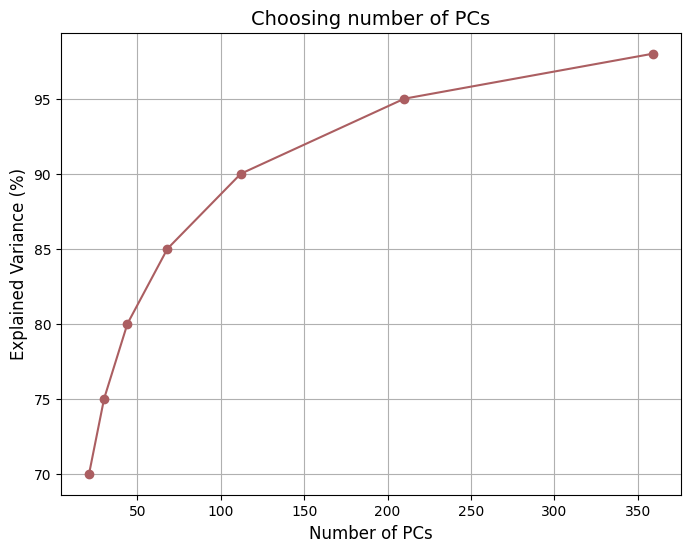

In [10]:
# Extract thresholds and number of principal components
var_percentages = [threshold * 100 for threshold, _ in results]
num_components = [num_components for _, num_components in results]

# Plot
plt.figure(figsize=(8, 6))
plt.plot(num_components, var_percentages, marker='o', linestyle='-', color='#AB5E61')
plt.title('Choosing number of PCs', fontsize=14)
plt.xlabel('Number of PCs', fontsize=12)
plt.ylabel('Explained Variance (%)', fontsize=12)
plt.grid(True)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

## Visualizing Dataset

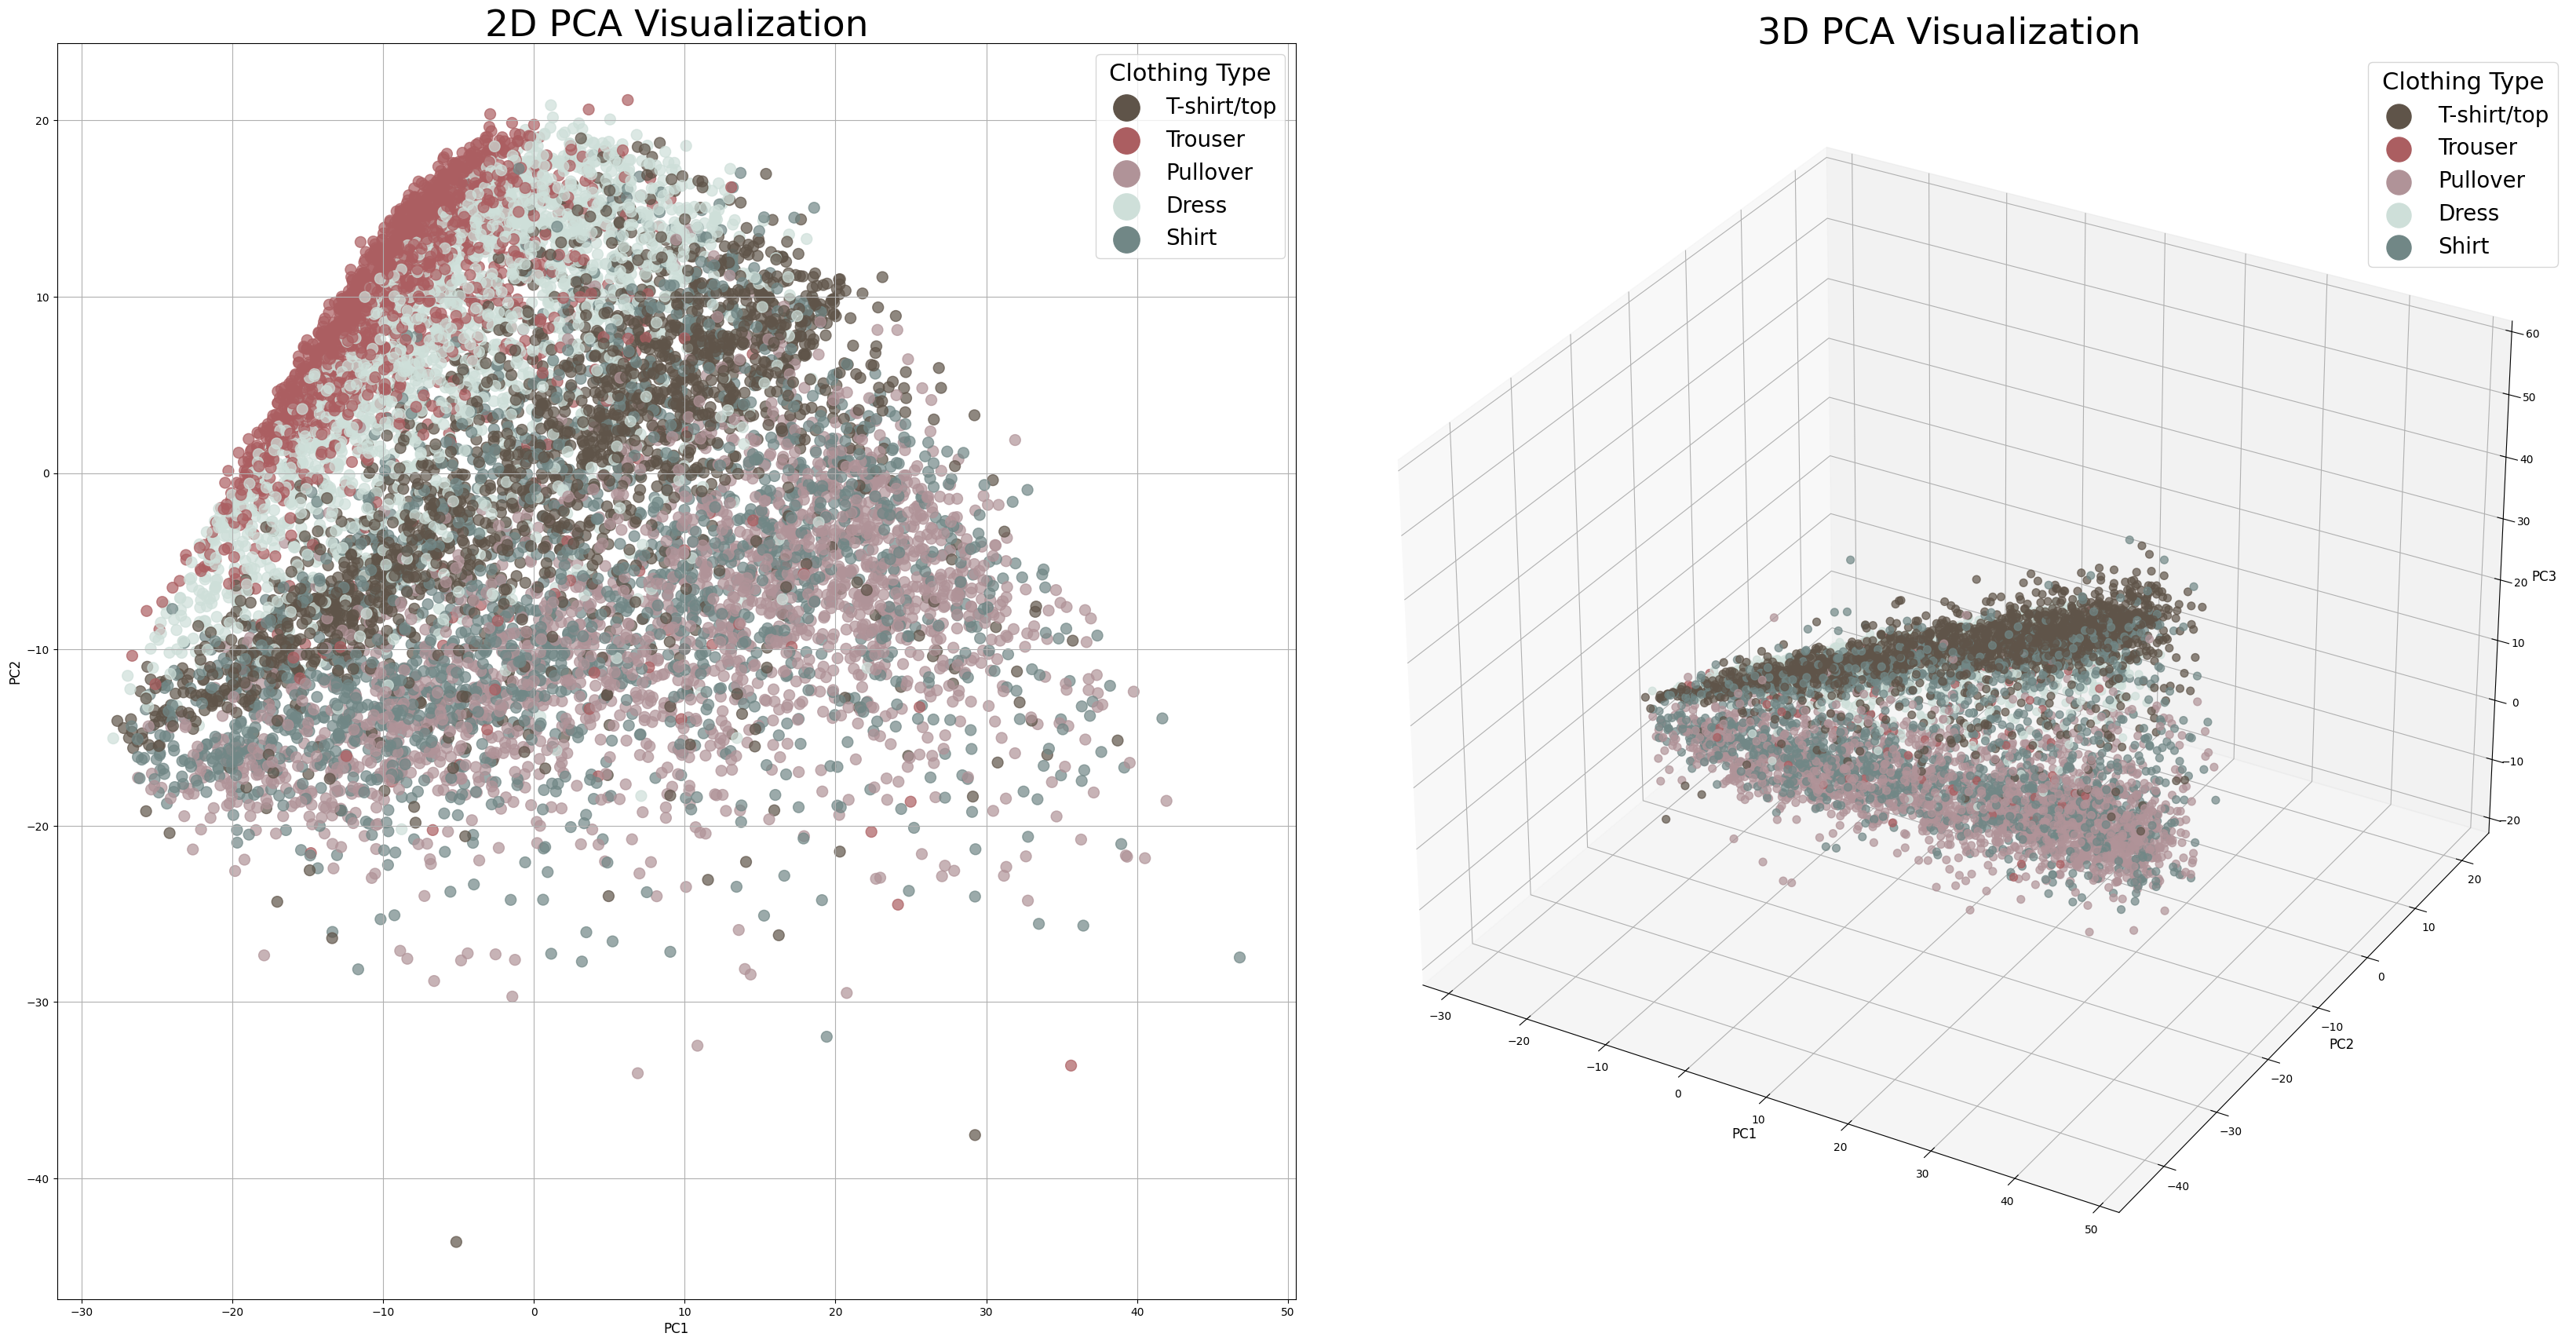

In [11]:
X_pca = pca.fit_transform(X_scaled)  # Get the transformed data

# --- PLOTTING ---
fig = plt.figure(figsize=(16, 8))

# 2D PCA subplot
ax1 = fig.add_subplot(121)
scatter_2d = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=[colors[label] for label in y], s=100, alpha=0.7)
ax1.set_title('2D PCA Visualization', fontsize=34)
ax1.set_xlabel('PC1', fontsize=12)
ax1.set_ylabel('PC2', fontsize=12)
ax1.grid(True)

# Legend for 2D PCA
for i, class_name in enumerate(class_names):
    ax1.scatter([], [], color=colors[i], label=class_name)
ax1.legend(title="Clothing Type", fontsize=20, title_fontsize=22, markerscale=4)

# 3D PCA subplot
ax2 = fig.add_subplot(122, projection='3d')
scatter_3d = ax2.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=[colors[label] for label in y], s=50, alpha=0.7)
ax2.set_title('3D PCA Visualization', fontsize=34)
ax2.set_xlabel('PC1', fontsize=12)
ax2.set_ylabel('PC2', fontsize=12)
ax2.set_zlabel('PC3', fontsize=12)

# Legend for 3D PCA
for i, class_name in enumerate(class_names):
    ax2.scatter([], [], [], color=colors[i], label=class_name)
ax2.legend(title="Clothing Type", fontsize=20, title_fontsize=22, markerscale=5)

plt.tight_layout()
fig.subplots_adjust(left=1, right=3, top=3, bottom=1)
plt.show()

## Reconstructing Images

### With n PCs

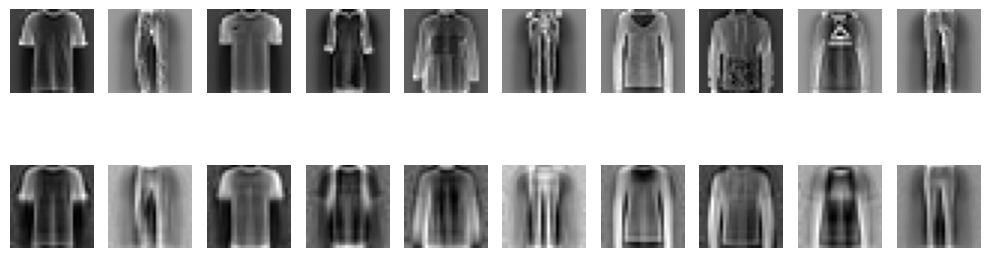

In [12]:
# Apply PCA
n_components = 112  # Number of PCs to keep
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# Reconstruct images using the top PCs
X_reconstructed = pca.inverse_transform(X_pca)

# Visualize original and reconstructed images
n_images = 10 
plt.figure(figsize=(10, 4))
for i in range(n_images):
    # Original image
    plt.subplot(2, n_images, i + 1)
    plt.imshow(X_scaled[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    
    # Reconstructed image
    plt.subplot(2, n_images, i + 1 + n_images)
    plt.imshow(X_reconstructed[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

### With 70-95% variance expl. PCs

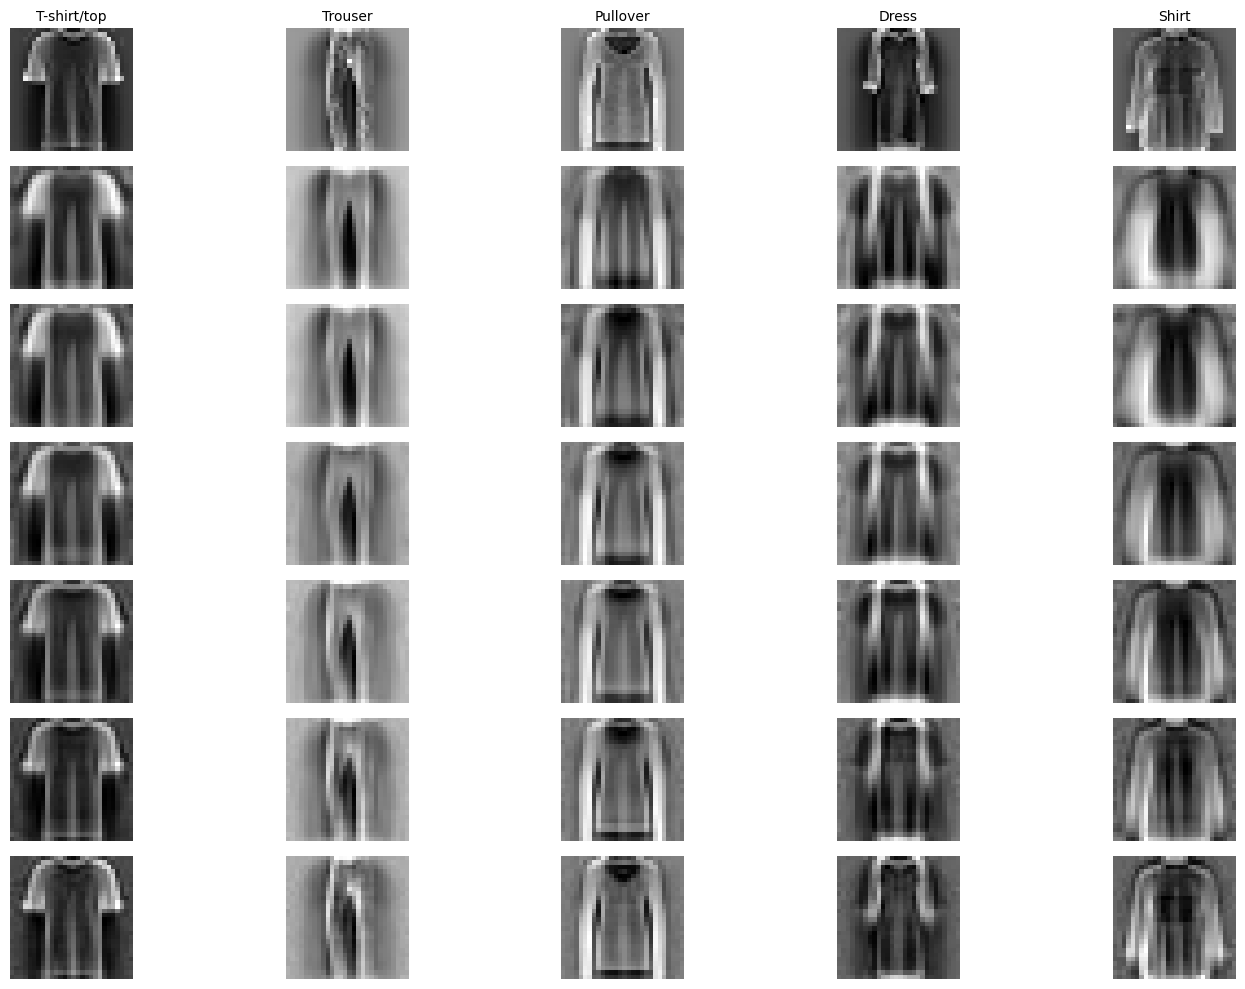

In [13]:
# Reload and prepare data
data = np.load('fashion_train.npy')
X_train = data[:, :-1]
y = data[:, -1]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# Select one sample per class for visualization
n_images = len(class_names)  # Number of images to visualize equals the number of classes
selected_indexes = []

for class_label in range(n_images):
    # Find the first index of the class
    class_indices = np.where(y == class_label)[0]
    selected_indexes.append(class_indices[0])  # Choose the first sample of each class

# Define number of principal components
num_pcs_list = [21, 30, 44, 68, 112, 210]  
    # Equal to  70, 75, 80, 85,  90, 95% variance explained

# Plotting
fig, axes = plt.subplots(len(num_pcs_list) + 1, n_images, figsize=(15, 10))

# Plot original images
for i, idx in enumerate(selected_indexes):
    axes[0, i].imshow(X_scaled[idx].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(class_names[i], fontsize=10)
axes[0, 0].set_ylabel('Original', fontsize=10)

# Plot reconstructions for different PCA components
for row, num_components in enumerate(num_pcs_list):
    # Apply PCA
    pca = PCA(n_components=num_components)
    X_pca = pca.fit_transform(X_scaled)
    X_reconstructed = pca.inverse_transform(X_pca)

    for i, idx in enumerate(selected_indexes):
        axes[row + 1, i].imshow(X_reconstructed[idx].reshape(28, 28), cmap='gray')
        axes[row + 1, i].axis('off')
    axes[row + 1, 0].set_ylabel(f"{num_components} PCs", fontsize=10)

plt.tight_layout()
plt.show()